# Definitive Meta-Analysis of RAMA/CAMA Across 12 Experiments

This notebook demonstrates a rigorous meta-analysis integrating 12 experiments (iterations 2-4)
evaluating RAMA and CAMA message-passing aggregation methods on RelBench datasets.

**Phases:**
- **A** - Evidence Registry & Quality Grading (GREEN/YELLOW/RED per task x experiment)
- **B** - Per-Task Cohen's d with Bootstrap CIs
- **C** - DerSimonian-Laird Random-Effects Meta-Analysis (3 pools)
- **D** - Critical Diagnostic Analyses (6 diagnostics)
- **E** - Publication Readiness Scorecard (7 dimensions, 0-3 each)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy>=1.13.0,<2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import warnings
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
from scipy import stats
from loguru import logger
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore", category=RuntimeWarning)

logger.remove()
import sys
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
print("Imports OK")

Imports OK


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/evaluation_iter5_definitive_meta/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['task_results'])} task results")

Loaded 23 task results


## Configuration

Tunable parameters for the meta-analysis. `N_BOOTSTRAP` controls the number of bootstrap
resamples for confidence intervals (original: 10,000).

In [5]:
# === Tunable parameters ===
N_BOOTSTRAP = 10_000  # Original: 10_000. Full value fits within time budget.
RANDOM_SEED = 42
RNG = np.random.default_rng(RANDOM_SEED)

## Data Structures & Loading Task Results

Convert the raw JSON task results into `TaskResult` dataclass objects for downstream analysis.

In [6]:
@dataclass
class TaskResult:
    """Per-task per-experiment comparison result."""
    exp_id: str
    iteration: int
    dataset: str
    task: str
    task_type: str  # "regression" or "classification"
    metric_name: str
    higher_is_better: bool
    baseline_seeds: list
    method_seeds: list
    method_name: str  # "RAMA" or "CAMA"
    architecture: str  # "HeteroSAGE" or "RelGNN"
    epochs_planned: int
    epochs_actual: int
    eval_split: str  # "test", "val", or "val=test"
    val_test_identical: bool = False
    gate_stats: Optional[dict] = None
    grade: str = ""
    grade_flags: list = field(default_factory=list)
    # Computed in Phase B
    cohens_d: float = 0.0
    cohens_d_ci: tuple = (0.0, 0.0)
    p_ttest: float = 1.0
    p_wilcoxon: float = 1.0
    raw_effect: float = 0.0
    raw_effect_ci: tuple = (0.0, 0.0)
    se_d: float = 0.0

    @property
    def n_seeds(self) -> int:
        return min(len(self.baseline_seeds), len(self.method_seeds))

    @property
    def unique_task_key(self) -> str:
        return f"{self.dataset}/{self.task}"


# Convert loaded JSON to TaskResult objects
results = []
for tr in data["task_results"]:
    results.append(TaskResult(
        exp_id=tr["exp_id"], iteration=tr["iteration"],
        dataset=tr["dataset"], task=tr["task"],
        task_type=tr["task_type"], metric_name=tr["metric_name"],
        higher_is_better=tr["higher_is_better"],
        baseline_seeds=tr["baseline_seeds"], method_seeds=tr["method_seeds"],
        method_name=tr["method_name"], architecture=tr["architecture"],
        epochs_planned=tr["epochs_planned"], epochs_actual=tr["epochs_actual"],
        eval_split=tr["eval_split"],
        val_test_identical=tr.get("val_test_identical", False),
        gate_stats=tr.get("gate_stats"),
        grade_flags=tr.get("grade_flags", []),
    ))
logger.info(f"Loaded {len(results)} task comparisons")

04:39:52|INFO   |Loaded 23 task comparisons


## Phase A: Evidence Registry & Quality Grading

Assign GREEN/YELLOW/RED grades to each task x experiment based on quality criteria:
seed count, epoch completion, gate stasis, val-only evaluation, degenerate baselines, etc.

In [7]:
def grade_evidence(results):
    """Assign GREEN/YELLOW/RED grades to each task x experiment."""
    for r in results:
        flags = list(r.grade_flags)  # keep any pre-set flags

        # 1. val_test_identical
        if r.val_test_identical:
            flags.append("val_test_identical")

        # 2. degenerate_baseline: CV < threshold
        bl = np.array(r.baseline_seeds, dtype=float)
        bl_mean = np.mean(bl) if len(bl) > 0 else 0.0
        bl_std = np.std(bl, ddof=1) if len(bl) > 1 else 0.0
        cv_threshold = 0.001
        if len(bl) > 1 and abs(bl_mean) > 1e-12 and bl_std / abs(bl_mean) < cv_threshold:
            flags.append("degenerate_baseline")
        if len(bl) > 1 and bl_std == 0.0:
            flags.append("zero_variance_baseline")

        # 3. seed_count
        if r.n_seeds < 5:
            flags.append(f"only_{r.n_seeds}_seeds")
        if r.n_seeds < 3:
            flags.append("fewer_than_3_seeds")

        # 4. epoch_deviation
        if r.epochs_actual < r.epochs_planned:
            flags.append(f"epoch_deviation_{r.epochs_actual}_vs_{r.epochs_planned}")

        # 5. gate_stasis
        if r.gate_stats and isinstance(r.gate_stats, dict):
            stasis = True
            n_edges_checked = 0
            for edge_key, edge_data in r.gate_stats.items():
                if isinstance(edge_data, dict):
                    gate_val = edge_data.get("mean_gate", edge_data.get("gate_bias_sigmoid_mean"))
                    if gate_val is not None and not (isinstance(gate_val, float) and math.isnan(gate_val)):
                        n_edges_checked += 1
                        if abs(gate_val - 0.5) > 0.02:
                            stasis = False
                            break
            if stasis and n_edges_checked > 0:
                flags.append("gate_stasis")

        # 6. val-only evaluation
        if r.eval_split == "val":
            flags.append("val_only_evaluation")

        # Assign grade
        critical_flags = {"val_test_identical", "degenerate_baseline",
                          "zero_variance_baseline", "fewer_than_3_seeds", "synthetic_data"}
        minor_flags = {"val_only_evaluation", "gate_stasis",
                       "no_individual_seeds_for_pooled"}

        has_critical = bool(critical_flags & set(flags))
        has_minor = bool(set(f for f in flags if f.startswith("epoch_deviation") or f.startswith("only_")) | (minor_flags & set(flags)))

        if has_critical:
            r.grade = "RED"
        elif has_minor:
            r.grade = "YELLOW"
        else:
            r.grade = "GREEN"

        r.grade_flags = flags

    grades = [r.grade for r in results]
    logger.info(f"Phase A grades: GREEN={grades.count('GREEN')}, "
                f"YELLOW={grades.count('YELLOW')}, RED={grades.count('RED')}")
    return results


results = grade_evidence(results)

04:39:52|INFO   |Phase A grades: GREEN=10, YELLOW=6, RED=7


## Phase B: Per-Task Cohen's d with Bootstrap CIs

Compute standardized effect sizes (Cohen's d) with bootstrap confidence intervals
and p-values (paired t-test + Wilcoxon) for each task comparison.

In [8]:
def compute_cohens_d_signed(baseline, method, higher_is_better):
    """Compute Cohen's d with sign such that positive = method is better."""
    n = len(baseline)
    if n < 2:
        return 0.0
    diff = method - baseline
    if not higher_is_better:
        diff = -diff  # flip so positive = method is better
    pooled_sd = np.sqrt((np.var(baseline, ddof=1) + np.var(method, ddof=1)) / 2.0)
    if pooled_sd < 1e-15:
        return 0.0
    return float(np.mean(diff) / pooled_sd)


def bootstrap_cohens_d_ci(baseline, method, higher_is_better, n_boot=N_BOOTSTRAP):
    """Bootstrap 95% CI for Cohen's d."""
    n = len(baseline)
    if n < 2:
        return (0.0, 0.0)
    boot_ds = np.empty(n_boot)
    for i in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        boot_ds[i] = compute_cohens_d_signed(baseline[idx], method[idx], higher_is_better)
    lo = float(np.nanpercentile(boot_ds, 2.5))
    hi = float(np.nanpercentile(boot_ds, 97.5))
    return (lo, hi)


def compute_all_effect_sizes(results):
    """Compute Cohen's d, bootstrap CI, p-values for each task result."""
    logger.info("Phase B: Computing effect sizes...")
    for r in results:
        bl = np.array(r.baseline_seeds, dtype=float)
        mt = np.array(r.method_seeds, dtype=float)
        n = min(len(bl), len(mt))
        if n < 2:
            r.cohens_d = 0.0
            r.cohens_d_ci = (0.0, 0.0)
            r.p_ttest = 1.0
            r.p_wilcoxon = 1.0
            r.raw_effect = 0.0
            r.raw_effect_ci = (0.0, 0.0)
            r.se_d = 0.0
            continue

        bl = bl[:n]
        mt = mt[:n]

        r.cohens_d = compute_cohens_d_signed(bl, mt, r.higher_is_better)
        r.cohens_d_ci = bootstrap_cohens_d_ci(bl, mt, r.higher_is_better)
        r.se_d = math.sqrt(2.0 / n + r.cohens_d ** 2 / (2.0 * n))

        # Paired t-test
        try:
            _, p_two = stats.ttest_rel(bl, mt)
            r.p_ttest = float(p_two) if not (math.isnan(p_two) or math.isinf(p_two)) else 1.0
        except Exception:
            r.p_ttest = 1.0

        # Wilcoxon signed-rank test
        try:
            diff_raw = mt - bl if r.higher_is_better else bl - mt
            if np.all(diff_raw == 0):
                r.p_wilcoxon = 1.0
            else:
                _, p_w = stats.wilcoxon(diff_raw, alternative="two-sided")
                r.p_wilcoxon = float(p_w)
        except Exception:
            r.p_wilcoxon = 1.0

        # Raw effect (in metric units)
        if r.higher_is_better:
            raw_diff = mt - bl
        else:
            raw_diff = bl - mt
        r.raw_effect = float(np.mean(raw_diff))
        se_raw = float(np.std(raw_diff, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
        r.raw_effect_ci = (r.raw_effect - 1.96 * se_raw, r.raw_effect + 1.96 * se_raw)

    logger.info("Phase B complete.")
    return results


def regrade_after_effect_sizes(results):
    """Re-grade after Phase B to catch inflated effect sizes (|d| > 5)."""
    for r in results:
        if abs(r.cohens_d) > 5.0 and "inflated_d" not in r.grade_flags:
            r.grade_flags.append(f"inflated_d_{abs(r.cohens_d):.1f}")
            if r.grade == "GREEN":
                r.grade = "YELLOW"
            if abs(r.cohens_d) > 20:
                r.grade = "RED"
    grades = [r.grade for r in results]
    logger.info(f"Phase A grades (after re-grade): GREEN={grades.count('GREEN')}, "
                f"YELLOW={grades.count('YELLOW')}, RED={grades.count('RED')}")
    return results


results = compute_all_effect_sizes(results)
results = regrade_after_effect_sizes(results)

# Print summary table
print(f"\n{'Exp':<15} {'Task':<40} {'d':>8} {'p':>8} {'Grade':<6}")
print("-" * 80)
for r in results:
    if r.dataset == "synthetic":
        continue
    print(f"{r.exp_id:<15} {r.unique_task_key:<40} "
          f"{r.cohens_d:>8.3f} {r.p_ttest:>8.4f} {r.grade:<6}")

04:39:52|INFO   |Phase B: Computing effect sizes...


04:39:56|INFO   |Phase B complete.


04:39:56|INFO   |Phase A grades (after re-grade): GREEN=8, YELLOW=8, RED=7



Exp             Task                                            d        p Grade 
--------------------------------------------------------------------------------
exp_id2_it2     rel-f1/driver-dnf                           1.125   0.1328 GREEN 
exp_id2_it2     rel-f1/driver-position                     -0.499   0.5578 GREEN 
exp_id3_it2     rel-stack/post-votes                        0.000   1.0000 RED   
exp_id3_it2     rel-stack/user-engagement                   3.215   0.0158 YELLOW
exp_id4_it2     rel-amazon/item-ltv                        10.828   0.0001 YELLOW
exp_id5_it2     rel-f1/driver-position                     11.834   0.0001 YELLOW
exp_id2_it3     rel-avito/ad-ctr                           -0.823   0.2784 YELLOW
exp_id3_it3     rel-f1/driver-position                     -0.349   0.5604 GREEN 
exp_id3_it3     rel-amazon/item-ltv                        -0.309   0.4298 GREEN 
exp_id4_it3     rel-f1/driver-dnf                           6.159   0.0018 YELLOW
exp_id4_it3     

## Phase C: DerSimonian-Laird Random-Effects Meta-Analysis

Pool effect sizes using the DerSimonian-Laird random-effects model across 4 subgroups:
GREEN-only, GREEN+YELLOW (primary), classification-only, and regression-only.

In [9]:
def dersimonian_laird(ds, ses):
    """DerSimonian-Laird random-effects meta-analysis."""
    k = len(ds)
    if k == 0:
        return {"pooled_d": 0.0, "se": 0.0, "ci_lo": 0.0, "ci_hi": 0.0,
                "tau2": 0.0, "I2": 0.0, "Q": 0.0, "Q_p": 1.0,
                "pred_lo": 0.0, "pred_hi": 0.0, "p_value": 1.0, "k": 0}
    if k == 1:
        d, se = ds[0], ses[0]
        return {"pooled_d": d, "se": se,
                "ci_lo": d - 1.96 * se, "ci_hi": d + 1.96 * se,
                "tau2": 0.0, "I2": 0.0, "Q": 0.0, "Q_p": 1.0,
                "pred_lo": d - 1.96 * se, "pred_hi": d + 1.96 * se,
                "p_value": 2 * (1 - stats.norm.cdf(abs(d / se))) if se > 0 else 1.0, "k": 1}

    d_arr = np.array(ds, dtype=float)
    se_arr = np.array(ses, dtype=float)
    var_arr = se_arr ** 2

    # Fixed-effect weights
    w = 1.0 / var_arr
    sum_w = np.sum(w)
    d_fe = np.sum(w * d_arr) / sum_w

    # Cochran's Q
    Q = float(np.sum(w * (d_arr - d_fe) ** 2))
    Q_p = float(1 - stats.chi2.cdf(Q, k - 1)) if k > 1 else 1.0

    # Between-study variance (tau^2)
    C = sum_w - np.sum(w ** 2) / sum_w
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

    # Random-effects weights
    w_star = 1.0 / (var_arr + tau2)
    sum_w_star = np.sum(w_star)
    d_re = float(np.sum(w_star * d_arr) / sum_w_star)
    se_re = float(1.0 / np.sqrt(sum_w_star))

    # I^2
    I2 = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0

    # p-value
    z = d_re / se_re if se_re > 0 else 0.0
    p_value = float(2 * (1 - stats.norm.cdf(abs(z))))

    # Prediction interval
    if k >= 3:
        t_crit = stats.t.ppf(0.975, k - 2)
        pred_se = math.sqrt(se_re ** 2 + tau2)
        pred_lo = d_re - t_crit * pred_se
        pred_hi = d_re + t_crit * pred_se
    else:
        pred_lo = d_re - 1.96 * se_re
        pred_hi = d_re + 1.96 * se_re

    return {"pooled_d": d_re, "se": se_re,
            "ci_lo": d_re - 1.96 * se_re, "ci_hi": d_re + 1.96 * se_re,
            "tau2": float(tau2), "I2": float(I2), "Q": Q, "Q_p": Q_p,
            "pred_lo": float(pred_lo), "pred_hi": float(pred_hi),
            "p_value": p_value, "k": k}


def run_meta_analyses(results):
    """Run 4 pooled meta-analyses."""
    real = [r for r in results if r.dataset != "synthetic"]
    green = [r for r in real if r.grade == "GREEN"]
    green_yellow = [r for r in real if r.grade in ("GREEN", "YELLOW")]
    classification = [r for r in green_yellow if r.task_type == "classification"]
    regression = [r for r in green_yellow if r.task_type == "regression"]

    def pool(subset, label):
        ds = [r.cohens_d for r in subset]
        ses = [r.se_d for r in subset]
        result = dersimonian_laird(ds, ses)
        logger.info(f"  {label}: k={result['k']}, pooled_d={result['pooled_d']:.3f}, "
                     f"CI=[{result['ci_lo']:.3f}, {result['ci_hi']:.3f}], "
                     f"p={result['p_value']:.4f}, I2={result['I2']:.1f}%")
        return result

    logger.info("Phase C: Running meta-analyses...")
    meta_results = {
        "green_only": pool(green, "GREEN-only"),
        "green_yellow": pool(green_yellow, "GREEN+YELLOW"),
        "classification_only": pool(classification, "Classification-only"),
        "regression_only": pool(regression, "Regression-only"),
    }
    logger.info("Phase C complete.")
    return meta_results


meta_results = run_meta_analyses(results)

04:39:56|INFO   |Phase C: Running meta-analyses...


04:39:56|INFO   |  GREEN-only: k=8, pooled_d=0.215, CI=[-0.718, 1.148], p=0.6515, I2=67.4%


04:39:56|INFO   |  GREEN+YELLOW: k=16, pooled_d=0.557, CI=[-0.364, 1.477], p=0.2361, I2=77.3%


04:39:56|INFO   |  Classification-only: k=5, pooled_d=1.740, CI=[0.359, 3.121], p=0.0135, I2=65.5%


04:39:56|INFO   |  Regression-only: k=11, pooled_d=-0.137, CI=[-1.174, 0.900], p=0.7958, I2=73.8%


04:39:56|INFO   |Phase C complete.


## Phase D: Critical Diagnostic Analyses

Run 6 diagnostics: val-test inflation, classification vs regression subgroup,
Amazon stability, gate learning, degenerate baselines, and Avito safety.

In [10]:
def _diag_val_test_inflation(results):
    """D1: Compare val-only vs test-evaluated effect sizes for same tasks."""
    task_groups = {}
    for r in results:
        key = r.unique_task_key
        if key not in task_groups:
            task_groups[key] = {"val": [], "test": []}
        if r.eval_split in ("val", "val=test"):
            task_groups[key]["val"].append(r)
        else:
            task_groups[key]["test"].append(r)
    inflation_entries = []
    for task_key, groups in task_groups.items():
        if groups["val"] and groups["test"]:
            for vr in groups["val"]:
                for tr in groups["test"]:
                    ratio = vr.cohens_d / tr.cohens_d if tr.cohens_d != 0 else (float("inf") if vr.cohens_d != 0 else 1.0)
                    inflation_entries.append({"task": task_key, "val_exp": vr.exp_id, "test_exp": tr.exp_id,
                                              "d_val": vr.cohens_d, "d_test": tr.cohens_d, "inflation_ratio": ratio})
    mean_inflation = (np.mean([e["inflation_ratio"] for e in inflation_entries if abs(e["inflation_ratio"]) < 100])
                      if inflation_entries else float("nan"))
    return {"entries": inflation_entries,
            "mean_inflation_ratio": float(mean_inflation) if not math.isnan(mean_inflation) else 0.0,
            "n_comparisons": len(inflation_entries)}


def _diag_class_vs_reg(results):
    """D2: Compare effect sizes between classification and regression tasks."""
    real = [r for r in results if r.dataset != "synthetic" and r.grade != "RED"]
    cls_ds = [r.cohens_d for r in real if r.task_type == "classification"]
    reg_ds = [r.cohens_d for r in real if r.task_type == "regression"]
    cls_mean = float(np.mean(cls_ds)) if cls_ds else 0.0
    reg_mean = float(np.mean(reg_ds)) if reg_ds else 0.0
    if cls_ds and reg_ds:
        try: _, p_val = stats.ttest_ind(cls_ds, reg_ds, equal_var=False); p_subgroup = float(p_val)
        except Exception: p_subgroup = 1.0
    else: p_subgroup = 1.0
    return {"classification_n": len(cls_ds), "classification_mean_d": cls_mean,
            "regression_n": len(reg_ds), "regression_mean_d": reg_mean, "p_subgroup_difference": p_subgroup}


def _diag_amazon_stability(results):
    """D3: Compare Amazon item-ltv across iterations."""
    amazon = [r for r in results if r.task == "item-ltv" and r.dataset == "rel-amazon"]
    entries = []
    for r in amazon:
        entries.append({"exp_id": r.exp_id, "iteration": r.iteration, "architecture": r.architecture,
                        "baseline_mean_mae": float(np.mean(r.baseline_seeds)),
                        "method_mean_mae": float(np.mean(r.method_seeds)),
                        "cohens_d": r.cohens_d, "eval_split": r.eval_split, "n_seeds": r.n_seeds})
    d_values = [e["cohens_d"] for e in entries]
    return {"experiments": entries, "d_range": (min(d_values) if d_values else 0.0, max(d_values) if d_values else 0.0),
            "d_sign_consistent": (all(d > 0 for d in d_values) or all(d < 0 for d in d_values)) if d_values else False,
            "n_experiments": len(entries)}


def _diag_gate_learning(results):
    """D4: Analyze gate learning across experiments with gate_stats."""
    gate_entries = []
    for r in results:
        if not r.gate_stats or not isinstance(r.gate_stats, dict): continue
        max_deviation, n_edges = 0.0, 0
        for edge_key, edge_data in r.gate_stats.items():
            if not isinstance(edge_data, dict): continue
            gate_val = edge_data.get("mean_gate", edge_data.get("gate_bias_sigmoid_mean"))
            if gate_val is None or (isinstance(gate_val, float) and math.isnan(gate_val)): continue
            dev = abs(gate_val - 0.5)
            max_deviation = max(max_deviation, dev)
            n_edges += 1
        gate_entries.append({"exp_id": r.exp_id, "task": r.unique_task_key,
                             "max_deviation": max_deviation, "n_edges": n_edges,
                             "stasis": max_deviation <= 0.02, "task_d": r.cohens_d})
    deviations = [e["max_deviation"] for e in gate_entries if not e["stasis"]]
    d_vals = [e["task_d"] for e in gate_entries if not e["stasis"]]
    corr, p_corr = (stats.spearmanr(deviations, d_vals) if len(deviations) >= 3 else (0.0, 1.0))
    stasis_count = sum(1 for e in gate_entries if e["stasis"])
    return {"entries": gate_entries, "n_with_gate_stats": len(gate_entries), "n_stasis": stasis_count,
            "correlation_deviation_vs_d": float(corr) if not math.isnan(corr) else 0.0,
            "correlation_p": float(p_corr) if not math.isnan(p_corr) else 1.0}


def _diag_degenerate_baselines(results):
    """D5: Identify degenerate baselines (near-zero variance)."""
    entries = []
    for r in results:
        bl = np.array(r.baseline_seeds, dtype=float)
        if len(bl) < 2: continue
        bl_std = float(np.std(bl, ddof=1))
        bl_mean = float(np.mean(bl))
        ratio = bl_std / abs(bl_mean) if abs(bl_mean) > 1e-12 else float("inf")
        if ratio < 0.01 or bl_std < 1e-6:
            entries.append({"exp_id": r.exp_id, "task": r.unique_task_key,
                            "baseline_mean": bl_mean, "baseline_std": bl_std,
                            "cv_ratio": ratio, "cohens_d": r.cohens_d,
                            "inflated_d": abs(r.cohens_d) > 10})
    return {"entries": entries, "n_degenerate": len(entries)}


def _diag_avito_safety(results):
    """D6: Avito safety assessment across iterations."""
    avito = [r for r in results if "avito" in r.dataset.lower() or "ad-ctr" in r.task]
    entries = []
    for r in avito:
        bl_mean = float(np.mean(r.baseline_seeds))
        mt_mean = float(np.mean(r.method_seeds))
        pct_diff = (mt_mean - bl_mean) / bl_mean * 100 if bl_mean != 0 else 0.0
        worst_seed_pct = 0.0
        for i in range(r.n_seeds):
            if i < len(r.baseline_seeds) and i < len(r.method_seeds):
                s_pct = (r.method_seeds[i] - r.baseline_seeds[i]) / r.baseline_seeds[i] * 100 if r.baseline_seeds[i] != 0 else 0.0
                worst_seed_pct = max(worst_seed_pct, s_pct)
        entries.append({"exp_id": r.exp_id, "iteration": r.iteration, "method_name": r.method_name,
                        "task": r.task, "baseline_mae": bl_mean, "method_mae": mt_mean,
                        "pct_diff": pct_diff, "worst_seed_pct_diff": worst_seed_pct,
                        "within_5pct": abs(pct_diff) <= 5.0, "cohens_d": r.cohens_d})
    within_5 = sum(1 for e in entries if e["within_5pct"])
    return {"entries": entries, "n_experiments": len(entries), "n_within_5pct": within_5,
            "safety_claim_supported": within_5 == len(entries) if entries else False}


def run_all_diagnostics(results):
    """Run all 6 diagnostic analyses."""
    logger.info("Phase D: Running diagnostic analyses...")
    diagnostics = {
        "val_test_inflation": _diag_val_test_inflation(results),
        "class_vs_reg": _diag_class_vs_reg(results),
        "amazon_stability": _diag_amazon_stability(results),
        "gate_learning": _diag_gate_learning(results),
        "degenerate_baselines": _diag_degenerate_baselines(results),
        "avito_safety": _diag_avito_safety(results),
    }
    logger.info("Phase D complete.")
    return diagnostics


diagnostics = run_all_diagnostics(results)

# Print diagnostic summaries
for name, diag in diagnostics.items():
    print(f"\n--- {name} ---")
    for k, v in diag.items():
        if k != "entries" and k != "experiments":
            print(f"  {k}: {v}")

04:39:56|INFO   |Phase D: Running diagnostic analyses...


04:39:56|INFO   |Phase D complete.



--- val_test_inflation ---
  mean_inflation_ratio: -3.6087025488761584
  n_comparisons: 8

--- class_vs_reg ---
  classification_n: 5
  classification_mean_d: 2.420068784033858
  regression_n: 11
  regression_mean_d: 1.795189656676139
  p_subgroup_difference: 0.7418711172492085

--- amazon_stability ---
  d_range: (-1.3771419312604964, 10.828142224474016)
  d_sign_consistent: False
  n_experiments: 3

--- gate_learning ---
  n_with_gate_stats: 8
  n_stasis: 8
  correlation_deviation_vs_d: 0.0
  correlation_p: 1.0

--- degenerate_baselines ---
  n_degenerate: 11

--- avito_safety ---
  n_experiments: 3
  n_within_5pct: 1
  safety_claim_supported: False


## Phase E: Publication Readiness Scorecard

7-dimension scorecard (0-3 each, max 21): effect size, significance, classification evidence,
safety, mechanism, reproducibility, and SOTA integration.

In [11]:
def publication_readiness_scorecard(results, meta_results, diagnostics):
    """7-dimension scorecard, each 0-3. Total max = 21."""
    scores = {}

    # 1. Pooled effect size (GREEN+YELLOW pool)
    gy = meta_results.get("green_yellow", {})
    d_gy = gy.get("pooled_d", 0.0)
    ci_lo = gy.get("ci_lo", 0.0)
    if d_gy <= 0: scores["effect_size"] = 0
    elif d_gy < 0.3: scores["effect_size"] = 1
    elif d_gy < 0.8: scores["effect_size"] = 2
    else: scores["effect_size"] = 3 if ci_lo > 0 else 2

    # 2. Statistical significance
    p_gy = gy.get("p_value", 1.0)
    if p_gy >= 0.10: scores["significance"] = 0
    elif p_gy >= 0.05: scores["significance"] = 1
    elif p_gy >= 0.01: scores["significance"] = 2
    else: scores["significance"] = 3

    # 3. Classification evidence
    cls = meta_results.get("classification_only", {})
    d_cls = cls.get("pooled_d", 0.0)
    p_cls = cls.get("p_value", 1.0)
    if d_cls <= 0: scores["classification_evidence"] = 0
    elif p_cls > 0.10: scores["classification_evidence"] = 1 if d_cls > 0 else 0
    elif p_cls > 0.05: scores["classification_evidence"] = 2
    else: scores["classification_evidence"] = 3

    # 4. Safety
    avito_diag = diagnostics.get("avito_safety", {})
    entries = avito_diag.get("entries", [])
    if not entries: scores["safety"] = 2
    else:
        worst_pct = max(abs(e.get("pct_diff", 0)) for e in entries)
        if worst_pct > 20: scores["safety"] = 0
        elif worst_pct > 10: scores["safety"] = 1
        elif worst_pct > 5: scores["safety"] = 2
        else: scores["safety"] = 3

    # 5. Mechanism evidence (gate learning)
    gate_diag = diagnostics.get("gate_learning", {})
    n_stasis = gate_diag.get("n_stasis", 0)
    n_total = gate_diag.get("n_with_gate_stats", 0)
    corr = gate_diag.get("correlation_deviation_vs_d", 0)
    if n_total == 0: scores["mechanism"] = 0
    elif n_stasis == n_total: scores["mechanism"] = 0
    elif n_stasis > n_total * 0.5: scores["mechanism"] = 1
    elif abs(corr) > 0.5: scores["mechanism"] = 3
    else: scores["mechanism"] = 2

    # 6. Reproducibility
    task_ds = {}
    for r in results:
        if r.dataset == "synthetic" or r.grade == "RED": continue
        key = r.unique_task_key
        if key not in task_ds: task_ds[key] = []
        task_ds[key].append(r.cohens_d)
    consistent_count, total_multi = 0, 0
    for key, ds in task_ds.items():
        if len(ds) >= 2:
            total_multi += 1
            if all(d > 0 for d in ds) or all(d < 0 for d in ds) or all(d == 0 for d in ds):
                consistent_count += 1
    if total_multi == 0: scores["reproducibility"] = 1
    else:
        ratio = consistent_count / total_multi
        if ratio < 0.5: scores["reproducibility"] = 0
        elif ratio < 0.7: scores["reproducibility"] = 1
        elif ratio < 0.9: scores["reproducibility"] = 2
        else: scores["reproducibility"] = 3

    # 7. SOTA integration benefit (RelGNN results)
    relgnn = [r for r in results if r.architecture == "RelGNN"]
    if not relgnn: scores["sota_integration"] = 0
    else:
        mean_d = np.mean([r.cohens_d for r in relgnn])
        if mean_d < 0: scores["sota_integration"] = 0
        elif mean_d < 0.2: scores["sota_integration"] = 1
        elif mean_d < 0.5: scores["sota_integration"] = 2
        else: scores["sota_integration"] = 3

    total = sum(scores.values())
    if total >= 15: rec_label = "READY"
    elif total >= 8: rec_label = "CONDITIONAL"
    else: rec_label = "NOT_READY"

    scorecard = {"scores": scores, "total": total, "max_possible": 21,
                 "recommendation_label": rec_label}
    logger.info(f"Phase E Scorecard: total={total}/21, recommendation={rec_label}")
    for dim, score in scores.items():
        logger.info(f"  {dim}: {score}/3")
    return scorecard


scorecard = publication_readiness_scorecard(results, meta_results, diagnostics)

04:39:56|INFO   |Phase E Scorecard: total=6/21, recommendation=NOT_READY


04:39:56|INFO   |  effect_size: 2/3


04:39:56|INFO   |  significance: 0/3


04:39:56|INFO   |  classification_evidence: 3/3


04:39:56|INFO   |  safety: 0/3


04:39:56|INFO   |  mechanism: 0/3


04:39:56|INFO   |  reproducibility: 1/3


04:39:56|INFO   |  sota_integration: 0/3


## Visualization: Forest Plot & Scorecard

**Left**: Forest plot showing per-task Cohen's d with 95% bootstrap CIs, colored by evidence grade.
Pooled estimates from random-effects meta-analysis shown as diamonds.

**Right**: Publication readiness scorecard radar chart (7 dimensions, 0-3 each).

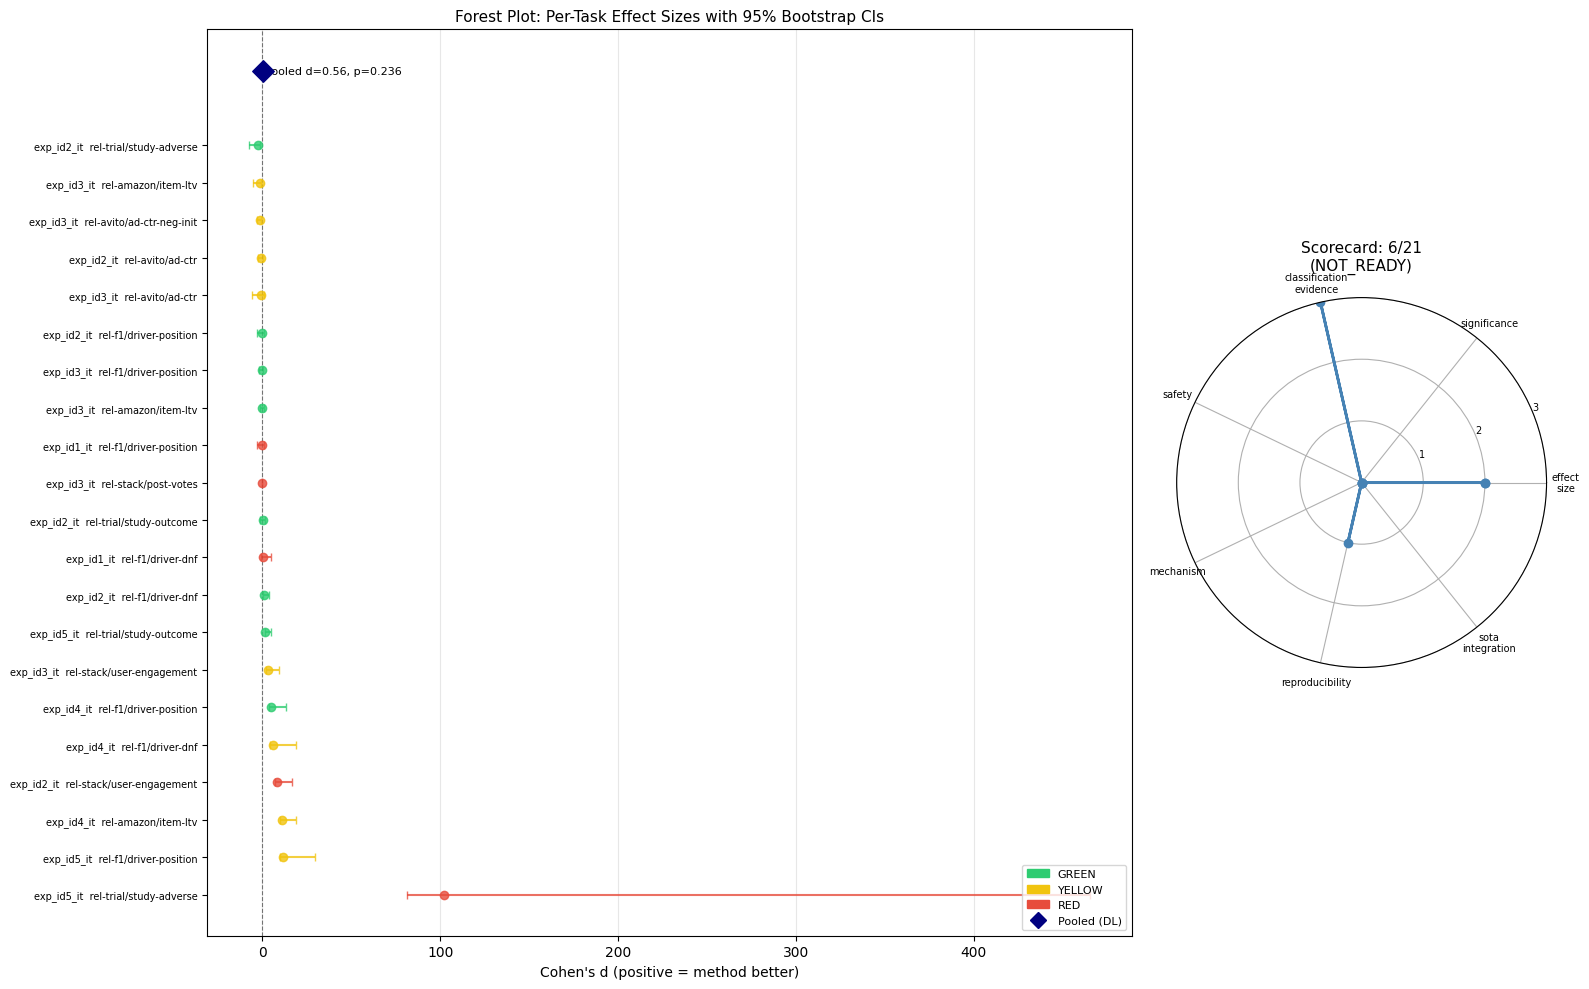


Key Results: Pooled d=0.557 [-0.364, 1.477], p=0.2361, I2=77.3%
Scorecard: 6/21 -> NOT_READY


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [2.5, 1]})

# --- Left: Forest Plot ---
ax = axes[0]
real_results = [r for r in results if r.dataset != "synthetic"]
real_results.sort(key=lambda r: r.cohens_d, reverse=True)

grade_colors = {"GREEN": "#2ecc71", "YELLOW": "#f1c40f", "RED": "#e74c3c"}
y_positions = list(range(len(real_results)))

for i, r in enumerate(real_results):
    color = grade_colors.get(r.grade, "gray")
    ci_lo, ci_hi = r.cohens_d_ci
    ax.errorbar(r.cohens_d, i, xerr=[[r.cohens_d - ci_lo], [ci_hi - r.cohens_d]],
                fmt='o', color=color, markersize=6, capsize=3, linewidth=1.5, alpha=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels([f"{r.exp_id[:10]}  {r.unique_task_key}" for r in real_results], fontsize=7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Add pooled estimate diamond
gy = meta_results["green_yellow"]
diamond_y = len(real_results) + 1
ax.scatter(gy["pooled_d"], diamond_y, marker='D', s=120, color='navy', zorder=5)
ax.plot([gy["ci_lo"], gy["ci_hi"]], [diamond_y, diamond_y], color='navy', linewidth=2.5)
ax.text(gy["ci_hi"] + 0.1, diamond_y, f"Pooled d={gy['pooled_d']:.2f}, p={gy['p_value']:.3f}",
        fontsize=8, va='center')

ax.set_xlabel("Cohen's d (positive = method better)", fontsize=10)
ax.set_title("Forest Plot: Per-Task Effect Sizes with 95% Bootstrap CIs", fontsize=11)
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in grade_colors.items()]
legend_patches.append(plt.Line2D([0], [0], marker='D', color='navy', linestyle='None', markersize=8, label='Pooled (DL)'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

# --- Right: Scorecard Radar ---
ax2 = axes[1]
ax2.set_visible(False)
ax_radar = fig.add_subplot(122, polar=True)

categories = list(scorecard["scores"].keys())
values = [scorecard["scores"][c] for c in categories]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
values_plot = values + values[:1]
angles_plot = angles + angles[:1]

ax_radar.plot(angles_plot, values_plot, 'o-', linewidth=2, color='steelblue')
ax_radar.fill(angles_plot, values_plot, alpha=0.25, color='steelblue')
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=7)
ax_radar.set_ylim(0, 3)
ax_radar.set_yticks([1, 2, 3])
ax_radar.set_yticklabels(['1', '2', '3'], fontsize=7)
ax_radar.set_title(f"Scorecard: {scorecard['total']}/{scorecard['max_possible']}\n"
                   f"({scorecard['recommendation_label']})", fontsize=11, pad=20)

plt.tight_layout()
plt.savefig("meta_analysis_results.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nKey Results: Pooled d={gy['pooled_d']:.3f} [{gy['ci_lo']:.3f}, {gy['ci_hi']:.3f}], "
      f"p={gy['p_value']:.4f}, I2={gy['I2']:.1f}%")
print(f"Scorecard: {scorecard['total']}/{scorecard['max_possible']} -> {scorecard['recommendation_label']}")